# Ejercicio de programación: Regresión Lineal Múltiple
## Predicción de Demanda de Bicicletas (Bike Sharing Dataset)

Se implementa la regresion lineal multivariable para predecir la **demanda diaria de bicicletas** (`cnt`)
a partir de variables climáticas y temporales del dataset **Bike Sharing** (UCI).

**Variable objetivo:** `cnt` — Total de bicicletas alquiladas por día (usuarios casuales + registrados).

**Metodos implementados:**
1. Descenso por el Gradiente (Gradient Descent)


## 1. Carga y Preparación del Dataset

Se carga el archivo `day.csv` del Bike Sharing Dataset.
Se seleccionan las variables predictoras más relevantes para la demanda diaria.


In [1]:

# Librerias para graficacion
from matplotlib import pyplot
%matplotlib inline


In [2]:
from pathlib import Path
import numpy as np

# Rutas candidatas al dataset
path_candidates = [
    Path('Datasets Primer Parcial/4-Bike Sharing/bike+sharing+dataset'),
    Path('../Datasets Primer Parcial/4-Bike Sharing/bike+sharing+dataset'),
    Path('../../Datasets Primer Parcial/4-Bike Sharing/bike+sharing+dataset'),
    Path('4-Bike Sharing/bike+sharing+dataset'),
]
path = next((p for p in path_candidates if (p / 'day.csv').exists()), None)
if path is None:
    raise FileNotFoundError('No se encontro la carpeta del dataset Bike Sharing.')

bike_path = path / 'day.csv'
print(f'Usando archivo: {bike_path.resolve()}')

data_raw = np.genfromtxt(bike_path, delimiter=',', skip_header=1)


feature_idx = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
target_idx  = 15  

X = data_raw[:, feature_idx]
y = data_raw[:, target_idx]
m = y.size

nombres_features = ['season', 'yr', 'mnth', 'holiday', 'weekday',
                    'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

print(f'Forma de la matriz de datos: {data_raw.shape}')
print(f'Ejemplos de entrenamiento (m): {m}')
print()
print('{:>12s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}'.format(
      'season','yr','mnth','holi','weekd','workd','wsit','temp','atemp','hum','wind','cnt'))
print('-'*100)
for i in range(8):
    row = ''.join([f'{X[i,j]:8.2f}' for j in range(X.shape[1])])
    print(f'{row}  {y[i]:8.0f}')


Usando archivo: D:\7mo Semestre\SIS420 Inteligencia Artificial\Primer Parcial\Parciales\PrimerParcial\Datasets Primer Parcial\4-Bike Sharing\bike+sharing+dataset\day.csv
Forma de la matriz de datos: (731, 16)
Ejemplos de entrenamiento (m): 731

      season      yr    mnth    holi   weekd   workd    wsit    temp   atemp     hum    wind     cnt
----------------------------------------------------------------------------------------------------
    1.00    0.00    1.00    0.00    6.00    0.00    2.00    0.34    0.36    0.81    0.16       985
    1.00    0.00    1.00    0.00    0.00    0.00    2.00    0.36    0.35    0.70    0.25       801
    1.00    0.00    1.00    0.00    1.00    1.00    1.00    0.20    0.19    0.44    0.25      1349
    1.00    0.00    1.00    0.00    2.00    1.00    1.00    0.20    0.21    0.59    0.16      1562
    1.00    0.00    1.00    0.00    3.00    1.00    1.00    0.23    0.23    0.44    0.19      1600
    1.00    0.00    1.00    0.00    4.00    1.00    1.00  

## 2. Seleccion de Variables y Normalizacion

<a id="section2"></a>
### 2.1 Normalizacion de caracteristicas

Las variables del dataset tienen escalas muy distintas:
- `cnt` va de ~22 a ~8714 bicicletas/día
- `temp` y `atemp` están normalizadas en [0,1] por el dataset original
- `mnth` va de 1 a 12 y `season` de 1 a 4

Sin normalización, el descenso por el gradiente converge muy lentamente o diverge.



In [3]:
def featureNormalize(X):

    X_norm = X.copy()
    mu    = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [4]:
# Llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada (mu):')
for n, v in zip(nombres_features, mu):
    print(f'  {n:>12s}: {v:.4f}')
print()
print('Desviacion estandar (sigma):')
for n, v in zip(nombres_features, sigma):
    print(f'  {n:>12s}: {v:.4f}')
print()
print('Primeras 3 filas normalizadas:')
print(X_norm[:3])


Media calculada (mu):
        season: 2.4966
            yr: 0.5007
          mnth: 6.5198
       holiday: 0.0287
       weekday: 2.9973
    workingday: 0.6840
    weathersit: 1.3953
          temp: 0.4954
         atemp: 0.4744
           hum: 0.6279
     windspeed: 0.1905

Desviacion estandar (sigma):
        season: 1.1100
            yr: 0.5000
          mnth: 3.4496
       holiday: 0.1670
       weekday: 2.0034
    workingday: 0.4649
    weathersit: 0.5445
          temp: 0.1829
         atemp: 0.1628
           hum: 0.1423
     windspeed: 0.0774

Primeras 3 filas normalizadas:
[[-1.34821315 -1.00136893 -1.60016072 -0.171981    1.49880863 -1.47122472
   1.11042659 -0.82666213 -0.67994602  1.25017133 -0.38789169]
 [-1.34821315 -1.00136893 -1.60016072 -0.171981   -1.49607732 -1.47122472
   1.11042659 -0.72109471 -0.74065231  0.47911298  0.74960172]
 [-1.34821315 -1.00136893 -1.60016072 -0.171981   -0.99692966  0.67970582
  -0.72604815 -1.63465665 -1.749767   -1.33927398  0.74663186]

In [22]:
# Split 75/25 del dataset
split_idx = int(0.75 * len(X_norm))

X_train_norm = X_norm[:split_idx]
y_train = y[:split_idx]
X_test_norm = X_norm[split_idx:]
y_test = y[split_idx:]

m_train = y_train.shape[0]
m_test = y_test.shape[0]

print('='*70)
print('SPLIT DEL DATASET BIKE SHARING (75/25)')
print('='*70)
print(f'Ejemplos TOTALES:        {len(X_norm):>6d}')
print(f'Ejemplos ENTRENAMIENTO:  {m_train:>6d}')
print(f'Ejemplos PRUEBA:         {m_test:>6d}')
print(f'Porcentaje train:        {(m_train/len(X_norm))*100:>6.1f}%')
print(f'Porcentaje test:         {(m_test/len(X_norm))*100:>6.1f}%')
print('='*70)


SPLIT DEL DATASET BIKE SHARING (75/25)
Ejemplos TOTALES:           731
Ejemplos ENTRENAMIENTO:     548
Ejemplos PRUEBA:            183
Porcentaje train:          75.0%
Porcentaje test:           25.0%


Despues de que `featureNormalize` es probada, se añade el termino de interseccion a `X_norm`.
Esta columna de unos permite al modelo aprender el intercepto (bias) θ₀.


In [ ]:
# Agregar término de intersección
X_train = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')


Forma de X_train con termino de interseccion: (548, 12)
  -> 12 parametros theta a aprender (1 intercepto + 11 features)

Forma de X_test con termino de interseccion: (183, 12)

Primeras 3 filas de X_train normalizadas (con intercepto):
[[ 1.         -1.34821315 -1.00136893 -1.60016072 -0.171981    1.49880863
  -1.47122472  1.11042659 -0.82666213 -0.67994602  1.25017133 -0.38789169]
 [ 1.         -1.34821315 -1.00136893 -1.60016072 -0.171981   -1.49607732
  -1.47122472  1.11042659 -0.72109471 -0.74065231  0.47911298  0.74960172]
 [ 1.         -1.34821315 -1.00136893 -1.60016072 -0.171981   -0.99692966
   0.67970582 -0.72604815 -1.63465665 -1.749767   -1.33927398  0.74663186]]


## 4. Funciones Matematicas: Costo y Descenso por el Gradiente

<a id="section4"></a>
### 4.1 Descenso por el gradiente

**Funcion de costo** (MSE):
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2$$

**Actualizacion de theta:**
$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$


In [6]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]  

    J = 0
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [7]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]  

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history


#### 4.1.1 Seleccionando coeficientes de aprendizaje

Se elige un valor para alpha y se ejecuta el descenso por el gradiente.
Se graficará J(θ) en función de las iteraciones para verificar convergencia.
Un alpha muy grande puede hacer diverger el costo; muy pequeño converge lento.


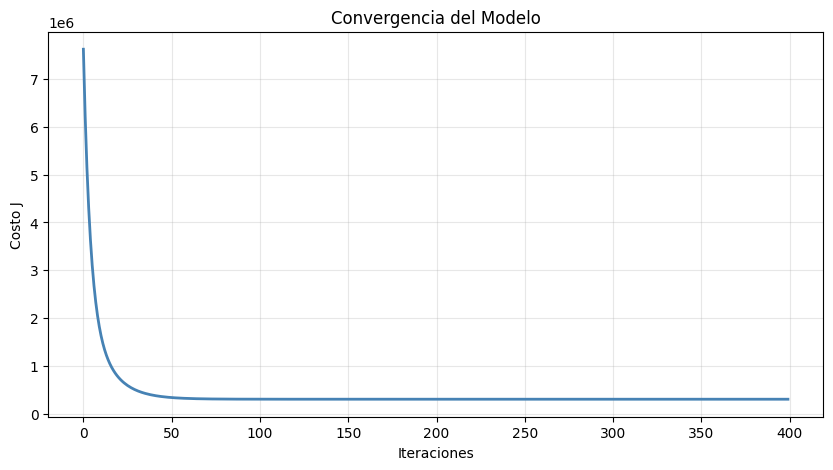

Parámetros theta (Gradient Descent):
  intercepto: 4546.3144
  season: 347.9354
  yr: 1063.4946
  mnth: 100.4832
  holiday: -77.6728
  weekday: 95.0190
  workingday: 14.1759
  weathersit: -286.1585
  temp: 374.8696
  atemp: 578.9593
  hum: -152.1413
  windspeed: -183.5023


In [ ]:
# Descenso por el Gradiente
alpha     = 0.1
num_iters = 400

theta_gradiente = np.zeros(X_train.shape[1])
theta_gradiente, J_history = gradientDescentMulti(X_train, y_train, theta_gradiente, alpha, num_iters)

pyplot.figure(figsize=(10, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Modelo')
pyplot.grid(True, alpha=0.3)
pyplot.show()

print('Parámetros theta (Gradient Descent):')
for n, t in zip(['intercepto'] + nombres_features, theta_gradiente):
    print(f'  {n}: {t:.4f}')

## 5. Entrenamiento del Modelo de Regresion Multiple

Una vez obtenidos los valores de theta, se calculan las predicciones
y se grafican contra los valores reales para evaluar visualmente la precision.


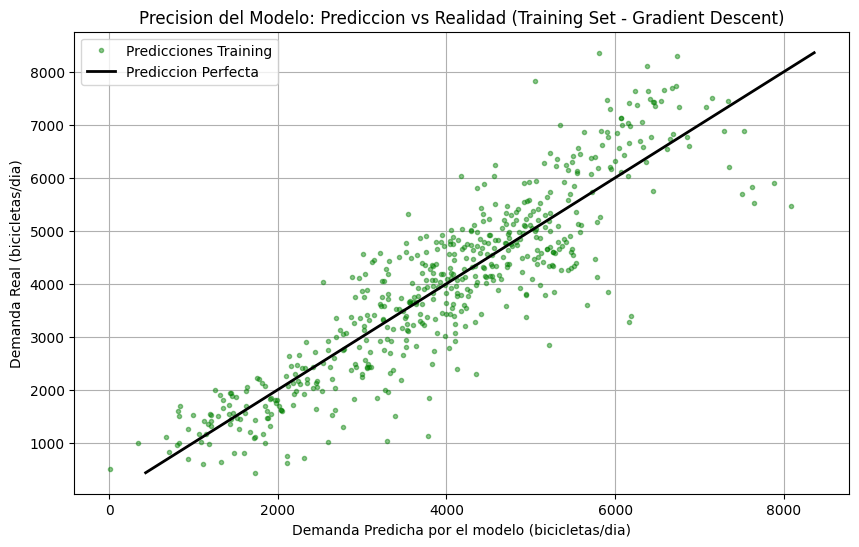

In [ ]:
# Predicciones en Training
predicciones_train_gd = np.dot(X_train, theta_gradiente)

pyplot.figure(figsize=(10, 5))
pyplot.plot(predicciones_train_gd, y_train, 'go', markersize=3, alpha=0.45)
pyplot.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k-', lw=2)
pyplot.xlabel('Predicción')
pyplot.ylabel('Real')
pyplot.title('Training Set - Predicciones vs Real')
pyplot.grid(True, alpha=0.3)
pyplot.show()


## 7. Evaluacion Matematica del Modelo

Se evalua el modelo con tres metricas calculadas **manualmente**:

- **MSE** (Error Cuadratico Medio): promedio de los errores al cuadrado.
  Un MSE más bajo indica predicciones más cercanas a los valores reales.
- **RMSE** (Raiz del Error Cuadratico Medio): mismo MSE pero en las unidades
  originales (bicicletas/dia). Facilita interpretar el error.
- **R²** (Coeficiente de determinacion): proporcion de la varianza total
  explicada por el modelo. R²=1 es prediccion perfecta, R²=0 equivale a
  predecir siempre la media.


In [ ]:
# Predicciones
pred_train_gd = np.dot(X_train, theta_gradiente)
pred_test_gd = np.dot(X_test, theta_gradiente)

def calc_metricas(y_true, y_pred):
    mse = np.mean(np.square(y_true - y_pred))
    rmse = np.sqrt(mse)
    ss_res = np.sum(np.square(y_true - y_pred))
    ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
    r2 = 1 - (ss_res / ss_tot)
    return mse, rmse, r2

mse_train, rmse_train, r2_train = calc_metricas(y_train, pred_train_gd)
mse_test, rmse_test, r2_test = calc_metricas(y_test, pred_test_gd)

print('\n' + '='*70)
print('EVALUACION - GRADIENT DESCENT')
print('='*70)
print(f'{'METRICA':<25} {'TRAINING':>15} {'TEST':>15} {'DIFERENCIA':>15}')
print('-'*70)
print(f'{'MSE':<25} {mse_train:>15.2f} {mse_test:>15.2f} {abs(mse_test-mse_train):>15.2f}')
print(f'{'RMSE':<25} {rmse_train:>15.2f} {rmse_test:>15.2f} {abs(rmse_test-rmse_train):>15.2f}')
print(f'{'R²':<25} {r2_train:>15.4f} {r2_test:>15.4f} {abs(r2_test-r2_train):>15.4f}')
print('='*70)

# Control de overfitting
if abs(r2_test - r2_train) > 0.1:
    print('\n⚠ OVERFITTING DETECTADO - Aplicando Ridge Regression (L2)\n')
    
    lambda_reg = 10
    theta_ridge = np.linalg.inv(X_train.T @ X_train + lambda_reg * np.eye(X_train.shape[1])) @ X_train.T @ y_train
    
    pred_train_ridge = np.dot(X_train, theta_ridge)
    pred_test_ridge = np.dot(X_test, theta_ridge)
    
    mse_train_r, rmse_train_r, r2_train_r = calc_metricas(y_train, pred_train_ridge)
    mse_test_r, rmse_test_r, r2_test_r = calc_metricas(y_test, pred_test_ridge)
    
    print('EVALUACION - RIDGE REGRESSION (λ=10)')
    print('='*70)
    print(f'{'METRICA':<25} {'TRAINING':>15} {'TEST':>15} {'DIFERENCIA':>15}')
    print('-'*70)
    print(f'{'MSE':<25} {mse_train_r:>15.2f} {mse_test_r:>15.2f} {abs(mse_test_r-mse_train_r):>15.2f}')
    print(f'{'RMSE':<25} {rmse_train_r:>15.2f} {rmse_test_r:>15.2f} {abs(rmse_test_r-rmse_train_r):>15.2f}')
    print(f'{'R²':<25} {r2_train_r:>15.4f} {r2_test_r:>15.4f} {abs(r2_test_r-r2_train_r):>15.4f}')
    print('='*70)
    
    if abs(r2_test_r - r2_train_r) < abs(r2_test - r2_train):
        print('\n✓ Ridge Regression reduce el overfitting')
    
    pred_train_final = pred_train_ridge
    pred_test_final = pred_test_ridge
    r2_train_final = r2_train_r
    r2_test_final = r2_test_r
else:
    print('\n✓ NO hay overfitting significativo')
    pred_train_final = pred_train_gd
    pred_test_final = pred_test_gd
    r2_train_final = r2_train
    r2_test_final = r2_test


EVALUACION - GRADIENT DESCENT
METRICA                          TRAINING            TEST      DIFERENCIA
----------------------------------------------------------------------
MSE                             605224.44      1288133.38       682908.94
RMSE                               777.96         1134.96          357.00
R²                                 0.7930          0.5772          0.2158

⚠ OVERFITTING DETECTADO - Aplicando Ridge Regression (L2)

EVALUACION - RIDGE REGRESSION (λ=10)
METRICA                          TRAINING            TEST      DIFERENCIA
----------------------------------------------------------------------
MSE                             616770.85      1282450.18       665679.33
RMSE                               785.35         1132.45          347.11
R²                                 0.7890          0.5791          0.2100

✓ Ridge Regression reduce el overfitting


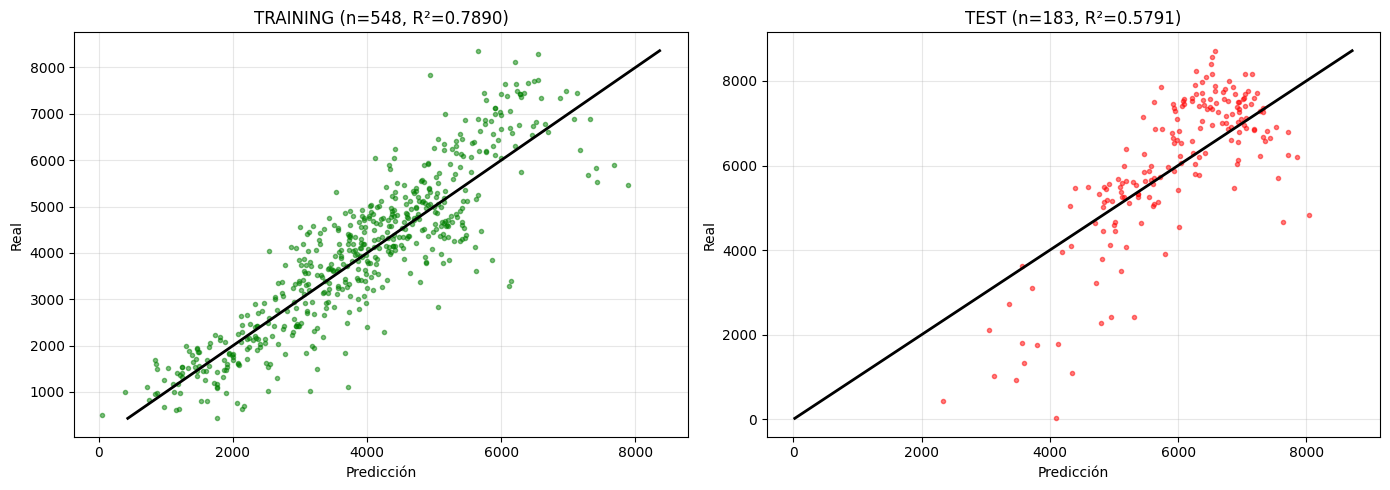

In [24]:
# Visualización: Training vs Test
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

# Training
axes[0].plot(pred_train_final, y_train, 'go', markersize=3, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k-', lw=2)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title(f'TRAINING (n={m_train}, R²={r2_train_final:.4f})')
axes[0].grid(True, alpha=0.3)

# Test
axes[1].plot(pred_test_final, y_test, 'ro', markersize=3, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k-', lw=2)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title(f'TEST (n={m_test}, R²={r2_test_final:.4f})')
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()


El R² esperado para un modelo lineal sobre Bike Sharing ronda el **80–85%**, ya que
la demanda tiene una relación aproximadamente lineal con temperatura y variables temporales.
La Ecuacion Normal entrega el resultado **óptimo** para regresión lineal.
